In [ ]:
import polars as pl
pl.Config.set_tbl_rows(-1)       # -1 means "show all rows"
pl.Config.set_tbl_cols(-1)       # -1 means "show all columns"
pl.Config.set_fmt_str_lengths(100)

: 

In [ ]:
pl.read_parquet("..//output//parquets//IDS2018_cleaned_v2.parquet").sink_parquet("..//output2//parquets//IDS2018_cleaned_v2.parquet")

In [ ]:
import polars as pl

# 1. Scan lazily
lazy_df = pl.scan_parquet("..//output2//parquets//IDS2018_cleaned_v2.parquet")
print("Plan loaded. Analyzing label distribution...")

# 2. Get counts (Using .len() to avoid the DeprecationWarning)
label_counts = lazy_df.select("Label").group_by("Label").len().collect()
print(label_counts)

train_frames = []
test_frames = []
val_frames = []

# 3. Stratified Split Logic
for label in label_counts["Label"]:
    # Filter for the class (Lazy)
    shuffled_lazy = lazy_df.filter(pl.col("Label") == label)
    
    # We SHUFFLE the class lazily first. 
    # This ensures that when we slice it, we get a random distribution.
    
    
    # Get the total count for this label to calculate slice offsets
    total_count = label_counts.filter(pl.col("Label") == label)["len"][0]
    
    # Calculate sizes for 70/20/10 split
    train_size = int(total_count * 0.7)
    test_size = int(total_count * 0.2)
    # Val size is the remainder
    
    # Use .slice(offset, length) - This is LAZY and RAM-friendly
    # Slice 1: Start at 0, take 70%
    train_frames.append(shuffled_lazy.slice(0, train_size))
    
    # Slice 2: Start after train, take 20%
    test_frames.append(shuffled_lazy.slice(train_size, test_size))
    
    # Slice 3: Start after test, take the rest
    val_frames.append(shuffled_lazy.slice(train_size + test_size, None))
    
    print(f"Added lazy slices for: {label}")

# 4. The SINK (The only part that actually processes the data)
print("Sinking to disk... This avoids loading the 2GB into RAM.")

pl.concat(train_frames).sink_parquet("..//output2//parquets//train//1_train_data.parquet")
pl.concat(test_frames).sink_parquet("..//output2//parquets//test//1_test_data.parquet")
pl.concat(val_frames).sink_parquet("..//output2//parquets//val//1_val_data.parquet")

print("Stratified split complete! 3 files generated: train, test, val.")

Plan loaded. Analyzing label distribution...
shape: (15, 2)
┌──────────────────────────┬─────────┐
│ Label                    ┆ len     │
│ ---                      ┆ ---     │
│ str                      ┆ u32     │
╞══════════════════════════╪═════════╡
│ Infilteration            ┆ 161934  │
│ SSH-Bruteforce           ┆ 187589  │
│ DoS attacks-GoldenEye    ┆ 41508   │
│ DoS attacks-Hulk         ┆ 461912  │
│ DoS attacks-SlowHTTPTest ┆ 139890  │
│ …                        ┆ …       │
│ FTP-BruteForce           ┆ 193360  │
│ DDOS attack-LOIC-UDP     ┆ 1730    │
│ Label                    ┆ 59      │
│ DDOS attack-HOIC         ┆ 686012  │
│ Benign                   ┆ 6112151 │
└──────────────────────────┴─────────┘
Added lazy slices for: Infilteration
Added lazy slices for: SSH-Bruteforce
Added lazy slices for: DoS attacks-GoldenEye
Added lazy slices for: DoS attacks-Hulk
Added lazy slices for: DoS attacks-SlowHTTPTest
Added lazy slices for: Bot
Added lazy slices for: Brute Force -Web
Ad

In [ ]:
import polars as pl

# 1. Scan the raw data
lf = pl.scan_parquet("..//output2//parquets//train//1_train_data.parquet")

# 2. Define the cleaning plan
exclude = ['Timestamp', 'Label']
numeric_cols = [col for col in lf.columns if col not in exclude]

# 3. Apply cleaning AND the sink in one go
(
    lf.with_columns([
        pl.col(numeric_cols).cast(pl.Float64, strict=False)
    ])
    .sink_parquet("..//output2//parquets//train//2_train_data_str_handled.parquet")
)

print("✅ Cleaned without any manual batching errors!")

C:\Users\akhiz\AppData\Local\Temp\ipykernel_14560\387897372.py:8: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  numeric_cols = [col for col in lf.columns if col not in exclude]


✅ Cleaned without any manual batching errors!


In [6]:
print(final_report)

shape: (78, 6)
┌───────────────────┬───────────────┬───────────┬───────────┬───────────────┬───────────────┐
│ Feature           ┆ Unique_Values ┆ Missing_% ┆ Zero_%    ┆ Std_Dev       ┆ Mean          │
│ ---               ┆ ---           ┆ ---       ┆ ---       ┆ ---           ┆ ---           │
│ str               ┆ i64           ┆ f64       ┆ f64       ┆ f64           ┆ f64           │
╞═══════════════════╪═══════════════╪═══════════╪═══════════╪═══════════════╪═══════════════╡
│ Dst Port          ┆ 62628         ┆ 0.000707  ┆ 1.039667  ┆ 21559.111333  ┆ 12674.840954  │
│ Protocol          ┆ 4             ┆ 0.000707  ┆ 1.039667  ┆ 4.405149      ┆ 8.049618      │
│ Flow Duration     ┆ 1948085       ┆ 0.000707  ┆ 0.390742  ┆ 8.2542e8      ┆ 9.6086e6      │
│ Tot Fwd Pkts      ┆ 2866          ┆ 0.000707  ┆ 0.0       ┆ 1769.577453   ┆ 30.305363     │
│ Tot Bwd Pkts      ┆ 2286          ┆ 0.000707  ┆ 28.107366 ┆ 152.311014    ┆ 5.853412      │
│ TotLen Fwd Pkts   ┆ 13335         ┆ 0.00070

In [ ]:
import polars as pl
import os
import shutil

input_path = "..//output2//parquets//train//2_train_data_str_handled.parquet"
output_path = "..//output2//parquets//train//3_train_data_deduplicated.parquet"
bucket_dir = "dup_check_buckets"
os.makedirs(bucket_dir, exist_ok=True)

print("🚀 Step 1: Partitioning data using Row-Level Hashing...")
lf = pl.scan_parquet(input_path)

# THE FIX: Use pl.struct(pl.all()).hash() to get ONE hash per row
for i in range(10):
    (
        lf.filter(
            pl.struct(pl.all()).hash(seed=42).mod(10) == i
        )
        .sink_parquet(f"{bucket_dir}/bucket_{i}.parquet")
    )
    print(f"✅ Bucket {i} written to disk.")

    
print("\n🧹 Step 2: Removing duplicates within buckets...")
for i in range(10):
    bucket_file = f"{bucket_dir}/bucket_{i}.parquet"
    if not os.path.exists(bucket_file): continue
    
    # Read the bucket and apply .unique()
    # Since identical rows are in the same bucket, this catches all duplicates
    (
        pl.read_parquet(bucket_file)
        .unique() 
        .write_parquet(f"{bucket_dir}/cleaned_bucket_{i}.parquet")
    )
    
    os.remove(bucket_file)
    print(f"✨ Bucket {i} cleaned.")

# 3. Final Merge
print("\n🔗 Step 3: Merging buckets into final gold dataset...")
pl.scan_parquet(f"{bucket_dir}/cleaned_bucket_*.parquet").sink_parquet(output_path)

# 4. Final Verification
initial_rows = pl.scan_parquet(input_path).select(pl.len()).collect().item()
final_rows = pl.scan_parquet(output_path).select(pl.len()).collect().item()
removed = initial_rows - final_rows
retention = (final_rows / initial_rows) * 100

print("\n" + "="*80)
print("✅ GLOBAL DEDUPLICATION COMPLETE")
print("="*80)
print(f"📊 Initial rows:  {initial_rows:,}")
print(f"📊 Final rows:    {final_rows:,}")
print(f"📉 Rows removed:  {removed:,}")
print(f"📈 Retention:     {retention:.2f}%")

# Cleanup
shutil.rmtree(bucket_dir)


🚀 Step 1: Partitioning data using Row-Level Hashing...
✅ Bucket 0 written to disk.
✅ Bucket 1 written to disk.
✅ Bucket 2 written to disk.
✅ Bucket 3 written to disk.
✅ Bucket 4 written to disk.
✅ Bucket 5 written to disk.
✅ Bucket 6 written to disk.
✅ Bucket 7 written to disk.
✅ Bucket 8 written to disk.
✅ Bucket 9 written to disk.

🧹 Step 2: Removing duplicates within buckets...
✨ Bucket 0 cleaned.
✨ Bucket 1 cleaned.
✨ Bucket 2 cleaned.
✨ Bucket 3 cleaned.
✨ Bucket 4 cleaned.
✨ Bucket 5 cleaned.
✨ Bucket 6 cleaned.
✨ Bucket 7 cleaned.
✨ Bucket 8 cleaned.
✨ Bucket 9 cleaned.

🔗 Step 3: Merging buckets into final gold dataset...

✅ GLOBAL DEDUPLICATION COMPLETE
📊 Initial rows:  5,798,971
📊 Final rows:    5,529,768
📉 Rows removed:  269,203
📈 Retention:     95.36%


In [ ]:
import polars as pl

# 1. SETUP & SCAN
input_path = "..//output2//parquets//train//3_train_data_deduplicated.parquet"
output_path = "..//output2//parquets//train//4_train_data_cleaned_invalid_inputs.parquet"

print("=" * 80)
print("🧹 POLARS CLEANING - INVALID FLOW REMOVAL")
print("=" * 80)

# Scan the data (Lazy - no RAM used yet)
lf = pl.scan_parquet(input_path)

# Initial State
initial_rows = lf.select(pl.len()).collect().item()
print(f"\n📊 Initial Dataset:")
print(f"    Total rows: {initial_rows:,}")
print(f"    Total columns: {len(lf.columns)}")

# =============================================================
# STEP 1 & 2: REMOVE DUPLICATES & INVALID FLOWS
# =============================================================
# We handle the 'Invalid Flow' check: (~(FwdPkts=0 AND BwdPkts=0 AND Duration=0))
# .fill_null(0) ensures we don't accidentally drop rows with valid Nulls
cleaned_lf = (
    lf
    .filter(
        ~(
            (pl.col("Tot Fwd Pkts").fill_null(0) == 0) & 
            (pl.col("Tot Bwd Pkts").fill_null(0) == 0) & 
            (pl.col("Flow Duration").fill_null(0) == 0)
        )
    )
    # STEP 3: Remove completely empty/corrupt lines (dropna how='all')
    .filter(~pl.all_horizontal(pl.all().is_null()))
)

# =============================================================
# STEP 4: EXECUTION & REPORTING
# =============================================================
# We 'sink' the data to run the plan without crashing the kernel
print(f"\n🔍 Processing filters and saving to disk...")
cleaned_lf.sink_parquet(output_path)

# Scan the newly created file for final stats
final_lf = pl.scan_parquet(output_path)
final_rows = final_lf.select(pl.len()).collect().item()
removed = initial_rows - final_rows
retention = (final_rows / initial_rows) * 100

print("\n" + "=" * 80)
print("✅ CLEANING COMPLETE")
print("=" * 80)
print(f"📊 Final Dataset:")
print(f"    Total rows: {final_rows:,}")
print(f"    Rows removed: {removed:,}")
print(f"    Retention rate: {retention:.2f}%")

# =============================================================
# STEP 5: LABEL DISTRIBUTION
# =============================================================
if "Label" in final_lf.columns:
    print(f"\n🎯 Label Distribution After Cleaning:")
    # We group by label, count, and calculate percentage
    dist = (
        final_lf.group_by("Label")
        .len()
        .with_columns(
            (pl.col("len") / final_rows * 100).round(2).alias("%")
        )
        .sort("len", descending=True)
        .collect()
    )
    
    # Configure Polars to show all labels
    with pl.Config(tbl_rows=-1):
        print(dist)

print("\n" + "=" * 80)
print(f"💾 Cleaned dataset stored in '{output_path}'")
print("=" * 80)

🧹 POLARS CLEANING - INVALID FLOW REMOVAL

📊 Initial Dataset:
    Total rows: 5,529,768
    Total columns: 80

🔍 Processing filters and saving to disk...


C:\Users\akhiz\AppData\Local\Temp\ipykernel_14560\205153360.py:18: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  print(f"    Total columns: {len(lf.columns)}")



✅ CLEANING COMPLETE
📊 Final Dataset:
    Total rows: 5,529,767
    Rows removed: 1
    Retention rate: 100.00%

🎯 Label Distribution After Cleaning:


C:\Users\akhiz\AppData\Local\Temp\ipykernel_14560\205153360.py:63: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  if "Label" in final_lf.columns:


shape: (14, 3)
┌──────────────────────────┬─────────┬───────┐
│ Label                    ┆ len     ┆ %     │
│ ---                      ┆ ---     ┆ ---   │
│ str                      ┆ u32     ┆ f64   │
╞══════════════════════════╪═════════╪═══════╡
│ Benign                   ┆ 4270487 ┆ 77.23 │
│ DDOS attack-HOIC         ┆ 473210  ┆ 8.56  │
│ DoS attacks-Hulk         ┆ 302033  ┆ 5.46  │
│ Bot                      ┆ 198386  ┆ 3.59  │
│ Infilteration            ┆ 113328  ┆ 2.05  │
│ SSH-Bruteforce           ┆ 87471   ┆ 1.58  │
│ DoS attacks-GoldenEye    ┆ 29038   ┆ 0.53  │
│ FTP-BruteForce           ┆ 27496   ┆ 0.5   │
│ DoS attacks-SlowHTTPTest ┆ 19462   ┆ 0.35  │
│ DoS attacks-Slowloris    ┆ 6997    ┆ 0.13  │
│ DDOS attack-LOIC-UDP     ┆ 1211    ┆ 0.02  │
│ Brute Force -Web         ┆ 427     ┆ 0.01  │
│ Brute Force -XSS         ┆ 161     ┆ 0.0   │
│ SQL Injection            ┆ 60      ┆ 0.0   │
└──────────────────────────┴─────────┴───────┘

💾 Cleaned dataset stored in 'train_data_clea

In [ ]:
# lets take a small sample to test if there is relation btw certain columns 
# 'Pkt Len Mean', 'Pkt Len Var', 'Pkt Len Std'
# 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std','Fwd Seg Size Avg',
# 'Bwd Pkt Len Mean','Bwd Pkt Len Std','Bwd Seg Size Avg',S
 
 
 

In [ ]:
import polars as pl

# --- CONFIGURATION ---
input_path = "..//output2//parquets//train//4_train_data_cleaned_invalid_inputs.parquet" 
output_path = "..//output2//parquets//train//5_train_data_optimized.parquet"

print("=" * 80)
print("POLARS: STREAMING FEATURE SELECTION & OPTIMIZATION")
print("=" * 80)

# 1. Scan the data to get available columns (Lazy, no RAM used)
lf = pl.scan_parquet(input_path)
available_columns = lf.columns

# =============================================================
# STEP 1: KEEP ONLY IMPORTANT FEATURES
# =============================================================
important_features = [
    'Timestamp', 'Src IP', 'Dst IP', 'Src Port', 'Dst Port', 'Protocol',
    'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'Flow Byts/s', 'Flow Pkts/s',
    'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Mean', 'Pkt Len Var', 'Pkt Len Std',
    'Fwd Pkt Len Mean', 'Bwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Std',
    'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Init Fwd Win Byts', 'Init Bwd Win Byts',
    'Active Mean', 'Idle Mean', 'Flow IAT Mean', 'Flow IAT Std',
    'Fwd IAT Mean', 'Bwd IAT Mean', 'Down/Up Ratio', 'Label'
]

# Ensure we only try to keep columns that actually exist in the file
keep_cols = [c for c in important_features if c in available_columns]
print(f"Selecting {len(keep_cols)} key features (Discarding the rest)")

# Identify categorical candidates dynamically
cat_candidates = [c for c in ['Protocol', 'Label'] if c in keep_cols]

# =============================================================
# STEP 2: BUILD THE OPTIMIZATION PLAN
# =============================================================
# THE FIX: Chain with_columns sequentially to avoid parallel assignment conflicts
optimized_lf = (
    lf.select(keep_cols)
    # Phase A: Downcast all numeric columns
    .with_columns([
        pl.col(pl.Float64).cast(pl.Float32),
        pl.col(pl.Int64).cast(pl.Int32),
    ])
    # Phase B: Convert specific columns to Categorical (Overwrites Phase A if needed)
    .with_columns([
        pl.col(cat_candidates).cast(pl.String).cast(pl.Categorical),
    ])
)

# Optional: Handle Timestamp safely if it exists
if 'Timestamp' in keep_cols:
    optimized_lf = optimized_lf.with_columns([
        pl.col('Timestamp').str.to_datetime(strict=False)
    ])

# =============================================================
# STEP 3: EXECUTE & SINK
# =============================================================
print("Processing and saving optimized dataset...")
optimized_lf.sink_parquet(output_path)

# =============================================================
# STEP 4: FINAL MEMORY REPORT
# =============================================================
df_final = pl.read_parquet(output_path)
mem_mb = df_final.estimated_size() / (1024 ** 2)

print("\n" + "=" * 80)
print("OPTIMIZATION COMPLETE")
print("=" * 80)
print(f"Final Shape: {df_final.shape}")
print(f"RAM footprint in Polars: {mem_mb:.2f} MB")

POLARS: STREAMING FEATURE SELECTION & OPTIMIZATION
Selecting 29 key features (Discarding the rest)
Processing and saving optimized dataset...


C:\Users\akhiz\AppData\Local\Temp\ipykernel_14560\3657797027.py:13: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  available_columns = lf.columns



OPTIMIZATION COMPLETE
Final Shape: (5529767, 29)
RAM footprint in Polars: 632.83 MB


In [ ]:
import polars as pl

print("Starting minimal feature engineering...")
# Assuming you loaded your data eagerly for notebook exploration:
df = pl.read_parquet("..//output//paquets//train//5_train_data_optimized.parquet")



Starting minimal feature engineering...


In [3]:
# ===== CELL 3: CLUSTER 1 - Traffic Balance (4 features) =====
"""
PURPOSE: Detect asymmetric communication patterns
- DDoS floods show extreme imbalance (many packets one way)
- Port scans have minimal responses
- Normal traffic is usually more balanced
"""
# We define total_pkts as a Polars expression for reuse
total_pkts_expr = pl.col('Tot Fwd Pkts') + pl.col('Tot Bwd Pkts')

df = df.with_columns([
    (pl.col('Tot Fwd Pkts') / (pl.col('Tot Bwd Pkts') + 1)).alias('fwd_bwd_pkt_ratio'),
    
    # min_horizontal replaces np.minimum
    pl.min_horizontal(
        pl.col('Tot Fwd Pkts') / (total_pkts_expr + 1),
        pl.col('Tot Bwd Pkts') / (total_pkts_expr + 1)
    ).alias('traffic_symmetry'),
    
    (pl.col('Tot Bwd Pkts') / (pl.col('Tot Fwd Pkts') + 1)).alias('response_ratio'),
    
    ((pl.col('Tot Fwd Pkts') > 0) & (pl.col('Tot Bwd Pkts') > 0)).cast(pl.Int32).alias('bidirectional_active')
])

print("Cluster 1: Traffic Balance (4 features added)")



Cluster 1: Traffic Balance (4 features added)


In [4]:
# ===== CELL 4: CLUSTER 2 - Temporal Patterns (3 features) =====
"""
PURPOSE: Identify abnormal timing patterns
- Automated attacks have very regular/irregular intervals
- Flooding attacks have extremely short intervals
- Normal traffic has natural variation
"""
df = df.with_columns([
    (pl.col('Flow IAT Std') / (pl.col('Flow IAT Mean') + 1)).alias('iat_regularity'),
    (total_pkts_expr / (pl.col('Flow Duration') + 0.001)).alias('flow_rate'),
    (pl.col('Fwd IAT Mean') - pl.col('Bwd IAT Mean')).abs().alias('timing_asymmetry')
])

print("Cluster 2: Temporal Patterns (3 features added)")



Cluster 2: Temporal Patterns (3 features added)


In [5]:
# ===== CELL 5: CLUSTER 3 - Packet Size Patterns (3 features) =====
"""
PURPOSE: Detect abnormal payload characteristics
- Many attacks use fixed-size packets (low variance)
- Scans often use minimal packets
- Exfiltration may show unusual size distributions
"""
df = df.with_columns([
    (pl.col('Pkt Len Std') / (pl.col('Pkt Len Mean') + 1)).alias('pkt_size_variance'),
    (pl.col('Fwd Pkt Len Mean') - pl.col('Bwd Pkt Len Mean')).abs().alias('fwd_bwd_size_diff'),
    (pl.col('Pkt Len Mean') < 100).cast(pl.Int32).alias('is_small_packet')
])

print("Cluster 3: Packet Size Patterns (3 features added)")



Cluster 3: Packet Size Patterns (3 features added)


In [6]:
# ===== CELL 6: CLUSTER 4 - Port Risk Indicators (3 features) =====
"""
PURPOSE: Flag potentially risky or unusual port usage
- Attacks often target specific vulnerable ports
- Ephemeral ports may indicate C&C communication
- Well-known ports have different risk profiles
"""
risky_ports = [21, 22, 23, 25, 445, 3389, 1433, 3306] 
web_ports = [80, 443, 8080, 8443]

df = df.with_columns([
    pl.col('Dst Port').is_in(risky_ports).cast(pl.Int32).alias('is_risky_port'),
    pl.col('Dst Port').is_in(web_ports).cast(pl.Int32).alias('is_web_traffic'),
    
    # pl.when().then() replaces pd.cut() for much faster binning
    pl.when(pl.col('Dst Port') <= 1024).then(0)
      .when(pl.col('Dst Port') <= 49151).then(1)
      .otherwise(2).alias('port_category')
])

print("Cluster 4: Port Risk Indicators (3 features added)")



Cluster 4: Port Risk Indicators (3 features added)


In [7]:
# ===== CELL 7: CLUSTER 5 - Composite Anomaly Score (1 feature) =====
"""
PURPOSE: Single metric combining multiple attack indicators
- High score = multiple suspicious characteristics present
- Useful for quick filtering and threshold-based detection
"""
df = df.with_columns([
    (
        (pl.col('traffic_symmetry') < 0.1).cast(pl.Int32) + 
        pl.col('is_small_packet') +  # Already Int32 from Cluster 3
        (pl.col('flow_rate') > pl.col('flow_rate').quantile(0.95)).cast(pl.Int32) + 
        (pl.col('iat_regularity') < 0.05).cast(pl.Int32) + 
        pl.col('is_risky_port')      # Already Int32 from Cluster 4
    ).alias('anomaly_score')
])

print("Cluster 5: Composite Anomaly Score (1 feature added)")



Cluster 5: Composite Anomaly Score (1 feature added)


In [11]:
# ===== CELL 8: Summary =====
print("\n" + "="*60)
print("FEATURE ENGINEERING COMPLETE")
print("="*60)
print(f"Final shape: {df.shape}")
print("\nAdded 14 high-impact features across 5 clusters")
print("\nNEW FEATURES:")
print("  - Traffic Balance (4): fwd_bwd_pkt_ratio, traffic_symmetry, response_ratio, bidirectional_active")
print("  - Temporal (3): iat_regularity, flow_rate, timing_asymmetry")
print("  - Packet Size (3): pkt_size_variance, fwd_bwd_size_diff, is_small_packet")
print("  - Port Risk (3): is_risky_port, is_web_traffic, port_category")
print("  - Anomaly Score (1): anomaly_score")

# Display first few rows of new features
print("\nSample of new features:")
new_cols = ['fwd_bwd_pkt_ratio', 'traffic_symmetry', 'response_ratio', 'bidirectional_active',
            'iat_regularity', 'flow_rate','timing_asymmetry','pkt_size_variance','fwd_bwd_size_diff','is_web_traffic','port_category', 'is_small_packet', 'is_risky_port', 'anomaly_score']

# Using pl.Config to ensure all columns print clearly
with pl.Config(tbl_cols=-1):
    print(df.select(new_cols).head())



FEATURE ENGINEERING COMPLETE
Final shape: (5529767, 43)

Added 14 high-impact features across 5 clusters

NEW FEATURES:
  - Traffic Balance (4): fwd_bwd_pkt_ratio, traffic_symmetry, response_ratio, bidirectional_active
  - Temporal (3): iat_regularity, flow_rate, timing_asymmetry
  - Packet Size (3): pkt_size_variance, fwd_bwd_size_diff, is_small_packet
  - Port Risk (3): is_risky_port, is_web_traffic, port_category
  - Anomaly Score (1): anomaly_score

Sample of new features:
shape: (5, 14)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬────────┬───────┬───────┬───────┬───────┬───────┬───────┐
│ fwd ┆ tra ┆ res ┆ bid ┆ iat ┆ flo ┆ tim ┆ pkt_si ┆ fwd_b ┆ is_we ┆ port_ ┆ is_sm ┆ is_ri ┆ anoma │
│ _bw ┆ ffi ┆ pon ┆ ire ┆ _re ┆ w_r ┆ ing ┆ ze_var ┆ wd_si ┆ b_tra ┆ categ ┆ all_p ┆ sky_p ┆ ly_sc │
│ d_p ┆ c_s ┆ se_ ┆ cti ┆ gul ┆ ate ┆ _as ┆ iance  ┆ ze_di ┆ ffic  ┆ ory   ┆ acket ┆ ort   ┆ ore   │
│ kt_ ┆ ymm ┆ rat ┆ ona ┆ ari ┆ --- ┆ ymm ┆ ---    ┆ ff    ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---  

In [ ]:


# ===== CELL 9 (Optional): Save Dataset =====
df.write_parquet("..//output//paquets//train//6_train_feature_engineered.parquet")
print("Dataset saved!")

Dataset saved!


In [ ]:
# load feature engineered dataset to check new features
df = pl.read_parquet("..//output//paquets//train//6_train_feature_engineered.parquet")
#print column names to verify new features are present
df.collect_schema().names()


['Timestamp',
 'Dst Port',
 'Protocol',
 'Flow Duration',
 'Tot Fwd Pkts',
 'Tot Bwd Pkts',
 'Flow Byts/s',
 'Flow Pkts/s',
 'Fwd Pkts/s',
 'Bwd Pkts/s',
 'Pkt Len Mean',
 'Pkt Len Var',
 'Pkt Len Std',
 'Fwd Pkt Len Mean',
 'Bwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Std',
 'Fwd Seg Size Avg',
 'Bwd Seg Size Avg',
 'Init Fwd Win Byts',
 'Init Bwd Win Byts',
 'Active Mean',
 'Idle Mean',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Fwd IAT Mean',
 'Bwd IAT Mean',
 'Down/Up Ratio',
 'Label',
 'fwd_bwd_pkt_ratio',
 'traffic_symmetry',
 'response_ratio',
 'bidirectional_active',
 'iat_regularity',
 'flow_rate',
 'timing_asymmetry',
 'pkt_size_variance',
 'fwd_bwd_size_diff',
 'is_small_packet',
 'is_risky_port',
 'is_web_traffic',
 'port_category',
 'anomaly_score']

In [16]:
len(df.collect_schema().names())


43

In [ ]:
import polars as pl
import polars.selectors as cs



print("\n" + "="*60)
print("PREPARING DATA FOR TRAINING")
print("="*60)

df = pl.read_parquet("..//output//paquets//train//6_train_feature_engineered.parquet")

# Extract useful features from Timestamp if it exists
if 'Timestamp' in df.columns:
    print("Extracting temporal features from Timestamp...")
    
    # Ensure Timestamp is a datetime type before extracting features
    time_col = pl.col('Timestamp')
    if df.schema['Timestamp'] == pl.String:
        time_col = time_col.str.to_datetime(strict=False)
        
    df = df.with_columns([
        time_col.dt.hour().alias('hour'),
        # Polars weekday is 1(Mon)-7(Sun). We subtract 1 to match Pandas 0-6 format.
        (time_col.dt.weekday() - 1).alias('day_of_week')
    ]).with_columns([
        # Now we can safely calculate weekend and business hours
        (pl.col('day_of_week') >= 5).cast(pl.Int32).alias('is_weekend'),
        ((pl.col('hour') >= 9) & (pl.col('hour') <= 17)).cast(pl.Int32).alias('is_business_hours')
    ])
    
    # Fill any nulls generated by invalid timestamps with 0 to prevent ML crashes
    df = df.with_columns([
        pl.col(['hour', 'day_of_week', 'is_weekend', 'is_business_hours']).fill_null(0)
    ])
    print("  Added: hour, day_of_week, is_weekend, is_business_hours")

# Drop non-numeric columns that can't be used for training
cols_to_drop = ['Label', 'Timestamp']



# Separate target from features
X = df.drop(cols_to_drop)

# In Polars, we use get_column to extract a Series. 
# Polars Series are immutable, so we don't need a .copy() like in Pandas.
y = df.get_column('Label')

print(f"\nFeatures (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"Number of features: {X.shape[1]}")


PREPARING DATA FOR TRAINING
Extracting temporal features from Timestamp...
  Added: hour, day_of_week, is_weekend, is_business_hours

Features (X): (5529767, 45)
Target (y): (5529767,)
Number of features: 45


In [ ]:
# Save X (already a DataFrame)
X.write_parquet("..//output//paquets//train//7_X_train.parquet")

# Convert the Series to a DataFrame, then save
y.to_frame().write_parquet("..//output//paquets//train//8_y_train.parquet")

In [ ]:
import polars as pl
import joblib
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

print("="*60)
print("STATEFUL ML ENCODING (POLARS -> SKLEARN)")
print("="*60)

X = pl.read_parquet("..//output//paquets//train//7_X_train.parquet")
y = pl.read_parquet("..//output//paquets//train//8_y_train.parquet").get_column('Label')  # Extract Series from DataFrame
# 1. IDENTIFY CATEGORICAL FEATURES
categorical_cols = [
    col for col, dtype in X.schema.items() 
    if dtype in [pl.String, pl.Categorical]
]

# =============================================================
# STEP 1: FIT & SAVE ONE-HOT ENCODER (FEATURES)
# =============================================================
if categorical_cols:
    print(f"Fitting OneHotEncoder for: {categorical_cols}")
    
    # handle_unknown='ignore' is the magic bullet. 
    # If the test set has a protocol it has never seen, it safely encodes it as all 0s!
    # sparse_output=False ensures it returns a dense array we can put back into Polars
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    
    # Scikit-learn expects Pandas or NumPy. Converting just these few columns is instantly fast.
    encoded_array = ohe.fit_transform(X.select(categorical_cols).to_pandas())
    
    # Save the fitted object for your inference pipeline
    joblib.dump(ohe, '..//output//downloads//encoders//1_ohe_feature_encoder.pkl')
    print("✅ Fitted OneHotEncoder saved to 'ohe_feature_encoder.pkl'")
    
    # Rebuild the Polars DataFrame with the new OHE columns
    feature_names = ohe.get_feature_names_out(categorical_cols)
    encoded_pl = pl.DataFrame(encoded_array, schema=list(feature_names))
    
    # Drop old string columns and horizontally concatenate the new one-hot columns
    X = pl.concat([X.drop(categorical_cols), encoded_pl], how="horizontal")
    print(f"📊 Final Feature Shape: {X.shape}")

# =============================================================
# STEP 2: FIT & SAVE LABEL ENCODER (TARGET)
# =============================================================
print("\nFitting LabelEncoder for Target...")

le = LabelEncoder()

# Fit and transform the target Series
# y.to_numpy() safely passes the Polars Series to sklearn
y_encoded_array = le.fit_transform(y.to_numpy())

# Save the fitted object
joblib.dump(le, '..//output//downloads//encoders//2_target_label_encoder.pkl')
print("✅ Fitted LabelEncoder saved to 'target_label_encoder.pkl'")

# (Optional) Convert back to Polars Series if you want to keep it in Polars
y_encoded = pl.Series("Label", y_encoded_array)

print(f"🎯 Classes mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

STATEFUL ML ENCODING (POLARS -> SKLEARN)
Fitting OneHotEncoder for: ['Protocol']
✅ Fitted OneHotEncoder saved to 'ohe_feature_encoder.pkl'
📊 Final Feature Shape: (5529767, 47)

Fitting LabelEncoder for Target...
✅ Fitted LabelEncoder saved to 'target_label_encoder.pkl'
🎯 Classes mapping: {'Benign': np.int64(0), 'Bot': np.int64(1), 'Brute Force -Web': np.int64(2), 'Brute Force -XSS': np.int64(3), 'DDOS attack-HOIC': np.int64(4), 'DDOS attack-LOIC-UDP': np.int64(5), 'DoS attacks-GoldenEye': np.int64(6), 'DoS attacks-Hulk': np.int64(7), 'DoS attacks-SlowHTTPTest': np.int64(8), 'DoS attacks-Slowloris': np.int64(9), 'FTP-BruteForce': np.int64(10), 'Infilteration': np.int64(11), 'SQL Injection': np.int64(12), 'SSH-Bruteforce': np.int64(13)}


In [ ]:
X.write_parquet("..//output//paquets//train//9_X_train_encoded.parquet")

# Convert the Series to a DataFrame, then save
y_encoded.to_frame().write_parquet("..//output//paquets//train//10_y_train_encoded.parquet")

In [6]:
import polars as pl

print("\nCleaning data...")

# 1. Identify floating-point columns
# Integers and Strings cannot legally hold Inf or NaN, so we skip them to save processing time.
float_cols = [
    col for col, dtype in X.schema.items() 
    if dtype in [pl.Float32, pl.Float64]
]

if float_cols:
    # 2. Count how many invalid values exist across the entire DataFrame
    # This checks for Inf, -Inf, NaN, and Null simultaneously
    invalid_check = X.select([
        (pl.col(c).is_infinite() | pl.col(c).is_nan() | pl.col(c).is_null()).sum().alias(c)
        for c in float_cols
    ])
    
    # Sum the results of all columns to get the grand total
    total_invalid = sum(invalid_check.row(0))
    
    if total_invalid > 0:
        print(f"  Found {total_invalid} invalid values (Inf/NaN/Null) - filling with 0")
        
        # 3. Apply the cleaning transformation in parallel
        # We flag Infinities and NaNs, convert them to Null, and then fill all Nulls with 0.0
        X = X.with_columns([
            pl.when(pl.col(c).is_infinite() | pl.col(c).is_nan())
            .then(None)
            .otherwise(pl.col(c))
            .fill_null(0.0)
            .alias(c)
            for c in float_cols
        ])
    else:
        print("  No invalid values found.")

print("Data cleaned")


Cleaning data...
  Found 45278 invalid values (Inf/NaN/Null) - filling with 0
Data cleaned


In [ ]:
import polars as pl
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler

print("="*60)
print("STANDARD SCALING (Z-SCORE NORMALIZATION)")
print("="*60)

scaler = StandardScaler()
feature_names = X.columns

print("Converting to 32-bit array for memory safety...")
# We explicitly cast to numpy float32 to prevent Scikit-Learn from doubling the RAM usage
X_numpy_32 = X.to_numpy().astype(np.float32)

print("Fitting StandardScaler and transforming data...")
X_scaled_array = scaler.fit_transform(X_numpy_32)

# Save the fitted scaler for your inference pipeline
joblib.dump(scaler, '..//output//downloads//encoders//3_standard_scaler.pkl')
print("Fitted StandardScaler saved to 'standard_scaler.pkl'")

# Reconstruct the Polars DataFrame, explicitly keeping it as Float32
X = pl.DataFrame(X_scaled_array, schema=feature_names).select(
    pl.all().cast(pl.Float32)
)

print(f"Standard Scaling complete. Final feature matrix shape: {X.shape}")

# Verify the scaling and memory
mem_mb = X.estimated_size() / (1024 ** 2)
print(f"RAM footprint in Polars: {mem_mb:.2f} MB")

STANDARD SCALING (Z-SCORE NORMALIZATION)
Converting to 32-bit array for memory safety...
Fitting StandardScaler and transforming data...
Fitted StandardScaler saved to 'standard_scaler.pkl'
Standard Scaling complete. Final feature matrix shape: (5529767, 47)
RAM footprint in Polars: 991.44 MB


In [ ]:
X.write_parquet("..//output//paquets//train//11_X_train_scaled.parquet")

In [ ]:
import numpy as np
import joblib
from sklearn.utils.class_weight import compute_sample_weight

print("\n" + "="*60)
print("HANDLING CLASS IMBALANCE (MULTICLASS)")
print("="*60)

# Assuming y_train is already loaded into memory as a NumPy array from the split
y_train = pl.read_parquet("..//output//paquets//train//10_y_train_encoded.parquet").get_column('Label')
# Load the fitted LabelEncoder to get the actual class names
le = joblib.load('..//output//downloads//encoders//2_target_label_encoder.pkl')
n_classes = len(le.classes_)

print(f"Number of classes: {n_classes}")
print("Using 'balanced' heuristic for sample weights...")

# Compute sample weights for the entire training set
# Formula: n_samples / (n_classes * np.bincount(y))
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Print out the distribution and the assigned weights
for i in range(n_classes):
    class_mask = (y_train == i)
    count = class_mask.sum()
    
    if count > 0:
        # Since 'balanced' assigns the same weight to all instances of a class, 
        # taking the mean() gives us that exact class weight.
        avg_weight = sample_weights[class_mask].mean()
        print(f"  Class {i} ({le.classes_[i]}): {count:,} samples, weight={avg_weight:.3f}")
    else:
        print(f"  Class {i} ({le.classes_[i]}): 0 samples (Not present in training split)")

# Save the weights to disk so they can be passed directly into the model's .fit() method
np.save("..//output//downloads//encoders//4_sample_weights_train.npy", sample_weights)
print("\nSample weights successfully computed and saved to 'sample_weights_train.npy'")


HANDLING CLASS IMBALANCE (MULTICLASS)
Number of classes: 14
Using 'balanced' heuristic for sample weights...
  Class 0 (Benign): 4,270,487 samples, weight=0.092
  Class 1 (Bot): 198,386 samples, weight=1.991
  Class 2 (Brute Force -Web): 427 samples, weight=925.020
  Class 3 (Brute Force -XSS): 161 samples, weight=2453.313
  Class 4 (DDOS attack-HOIC): 473,210 samples, weight=0.835
  Class 5 (DDOS attack-LOIC-UDP): 1,211 samples, weight=326.163
  Class 6 (DoS attacks-GoldenEye): 29,038 samples, weight=13.602
  Class 7 (DoS attacks-Hulk): 302,033 samples, weight=1.308
  Class 8 (DoS attacks-SlowHTTPTest): 19,462 samples, weight=20.295
  Class 9 (DoS attacks-Slowloris): 6,997 samples, weight=56.450
  Class 10 (FTP-BruteForce): 27,496 samples, weight=14.365
  Class 11 (Infilteration): 113,328 samples, weight=3.485
  Class 12 (SQL Injection): 60 samples, weight=6583.056
  Class 13 (SSH-Bruteforce): 87,471 samples, weight=4.516

Sample weights successfully computed and saved to 'sample_wei

In [3]:
import polars as pl
import numpy as np
import xgboost as xgb
import joblib

print("="*60)
print("TRAINING XGBOOST MODEL (CPU HISTOGRAM MODE WITH VALIDATION)")
print("="*60)

# ================================
# 1. Load the preprocessed data
# ================================
print("Loading training data arrays into memory...")
X_train = pl.read_parquet("..//output//parquets//train//11_X_train_scaled.parquet") 
y_train = pl.read_parquet("..//output//parquets//train//10_y_train_encoded.parquet").get_column('Label')
sample_weights = np.load("..//output//downloads//encoders//4_sample_weights_train.npy")

print("Loading validation data arrays into memory...")
# UPDATE THESE PATHS to point to your validation data
X_val = pl.read_parquet(f"../output/parquets/val/11_X_val_scaled.parquet")
y_val = pl.read_parquet(f"../output/parquets/val/10_y_val_encoded.parquet").get_column('Label')
n_classes = len(np.unique(y_train))
print(f"Data loaded. Training for {n_classes} classes.")

# ================================
# 2. Configure CPU-based parameters
# ================================
params = {
    # multi:softprob outputs exact probabilities for each class
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',
    'num_class': n_classes,
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_estimators': 100,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    
    # CRITICAL FOR CPU: Uses memory-efficient histogram binning
    'tree_method': 'hist',    
    
    # Uses all available CPU cores
    'n_jobs': -1,
    
    # Stops training if validation loss doesn't improve for 10 consecutive trees
    'early_stopping_rounds': 10 
}

print("\nParameters:")
for k, v in params.items():
    print(f"  {k}: {v}")

# Create the model
model = xgb.XGBClassifier(**params)

print("\nTraining with detailed logs...\n")

# ================================
# 3. Model Training
# ================================
# We pass both the training and validation sets to eval_set.
# The model uses the last item in eval_set (X_val, y_val) for early stopping.
model.fit(
    X_train, 
    y_train,
    sample_weight=sample_weights,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=2 # Print log every 10 trees
)

print("\nTraining complete!")

# ================================
# 4. Save the Final Model
# ================================
# Save the model in XGBoost's native JSON format (safer than pickle)
model.save_model("..//output//downloads//models//xgboost_ids_model2.json")
print("Model saved to 'xgboost_ids_model.json'")

TRAINING XGBOOST MODEL (CPU HISTOGRAM MODE WITH VALIDATION)
Loading training data arrays into memory...
Loading validation data arrays into memory...
Data loaded. Training for 14 classes.

Parameters:
  objective: multi:softprob
  eval_metric: mlogloss
  num_class: 14
  max_depth: 6
  learning_rate: 0.1
  n_estimators: 100
  subsample: 0.8
  colsample_bytree: 0.8
  random_state: 42
  tree_method: hist
  n_jobs: -1
  early_stopping_rounds: 10

Training with detailed logs...

[0]	validation_0-mlogloss:2.18469	validation_1-mlogloss:2.18329
[2]	validation_0-mlogloss:1.74150	validation_1-mlogloss:1.73730
[4]	validation_0-mlogloss:1.43678	validation_1-mlogloss:1.43292
[6]	validation_0-mlogloss:1.21156	validation_1-mlogloss:1.21062
[8]	validation_0-mlogloss:1.04198	validation_1-mlogloss:1.02646
[10]	validation_0-mlogloss:0.90931	validation_1-mlogloss:0.88087
[12]	validation_0-mlogloss:0.79140	validation_1-mlogloss:0.75885
[14]	validation_0-mlogloss:0.69672	validation_1-mlogloss:0.64625
[16]	v

In [8]:
X_train.columns

['Dst Port',
 'Flow Duration',
 'Tot Fwd Pkts',
 'Tot Bwd Pkts',
 'Flow Byts/s',
 'Flow Pkts/s',
 'Fwd Pkts/s',
 'Bwd Pkts/s',
 'Pkt Len Mean',
 'Pkt Len Var',
 'Pkt Len Std',
 'Fwd Pkt Len Mean',
 'Bwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Std',
 'Fwd Seg Size Avg',
 'Bwd Seg Size Avg',
 'Init Fwd Win Byts',
 'Init Bwd Win Byts',
 'Active Mean',
 'Idle Mean',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Fwd IAT Mean',
 'Bwd IAT Mean',
 'Down/Up Ratio',
 'fwd_bwd_pkt_ratio',
 'traffic_symmetry',
 'response_ratio',
 'bidirectional_active',
 'iat_regularity',
 'flow_rate',
 'timing_asymmetry',
 'pkt_size_variance',
 'fwd_bwd_size_diff',
 'is_small_packet',
 'is_risky_port',
 'is_web_traffic',
 'port_category',
 'anomaly_score',
 'hour',
 'day_of_week',
 'is_weekend',
 'is_business_hours',
 'Protocol_0.0',
 'Protocol_17.0',
 'Protocol_6.0']

In [5]:
import numpy as np
import xgboost as xgb
import joblib
from sklearn.metrics import classification_report, confusion_matrix

print("="*60)
print("MODEL EVALUATION: TRAINING DATA SANITY CHECK")
print("="*60)

# 1. Load the Label Encoder for human-readable class names
print("Loading label encoder...")
le = joblib.load('..//output//downloads//encoders//2_target_label_encoder.pkl')
class_names = le.classes_

# 2. Load the Training Data
print("Loading training data matrices...")


# 3. Load the Trained Model
print("Loading trained XGBoost model...")
model = xgb.XGBClassifier()
model.load_model("..//output/downloads/models//xgboost_ids_model.json")

# 4. Generate Predictions
print("Generating predictions on training data...")
y_pred = model.predict(X_train)

# 5. Print Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT (TRAINING SET)")
print("="*60)
# digits=4 gives you precision up to 4 decimal places, great for academic reporting
report = classification_report(y_train, y_pred, target_names=class_names, digits=4)
print(report)

# 6. Print Confusion Matrix
print("\n" + "="*60)
print("CONFUSION MATRIX")
print("="*60)
cm = confusion_matrix(y_train, y_pred)
print(cm)

MODEL EVALUATION: TRAINING DATA SANITY CHECK
Loading label encoder...
Loading training data matrices...
Loading trained XGBoost model...
Generating predictions on training data...

CLASSIFICATION REPORT (TRAINING SET)
                          precision    recall  f1-score   support

                  Benign     0.9998    0.8890    0.9412   4270487
                     Bot     1.0000    1.0000    1.0000    198386
        Brute Force -Web     0.1294    1.0000    0.2291       427
        Brute Force -XSS     0.1244    1.0000    0.2213       161
        DDOS attack-HOIC     1.0000    1.0000    1.0000    473210
    DDOS attack-LOIC-UDP     1.0000    1.0000    1.0000      1211
   DoS attacks-GoldenEye     0.9982    1.0000    0.9991     29038
        DoS attacks-Hulk     1.0000    1.0000    1.0000    302033
DoS attacks-SlowHTTPTest     0.9999    1.0000    1.0000     19462
   DoS attacks-Slowloris     0.9820    1.0000    0.9909      6997
          FTP-BruteForce     1.0000    1.0000    1.0000

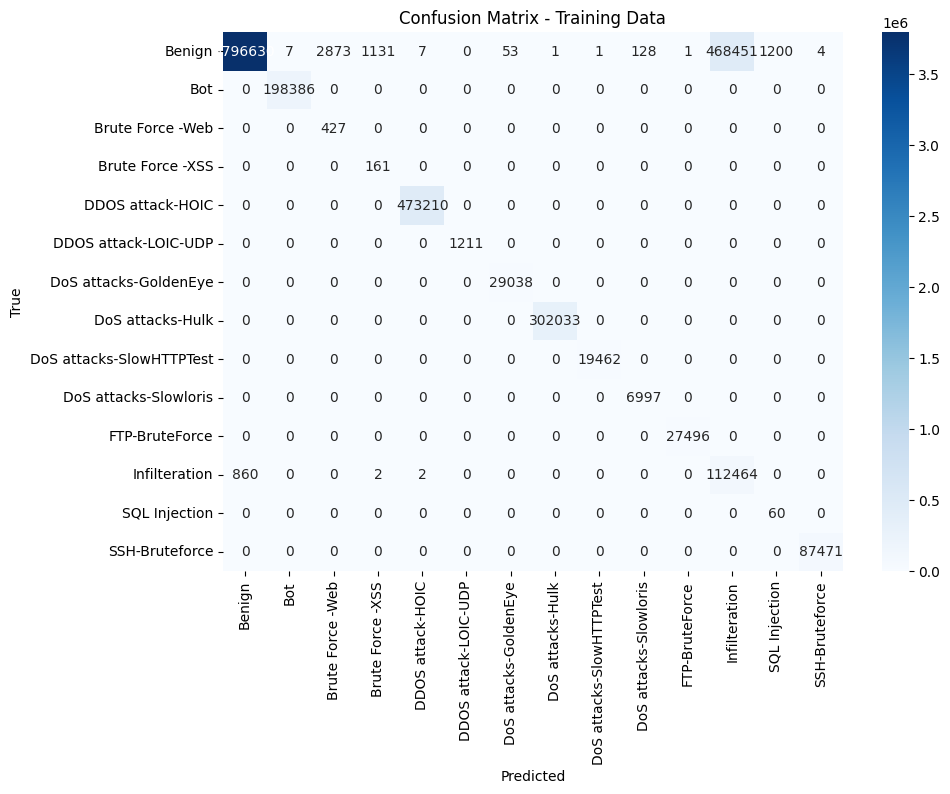

In [6]:
# visualize confusion matrix with class names
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Training Data')
plt.show()

Results are somewhat satisfactory but still below required threshold
before changing model or tuning them lets fix the pipeline

any attribute engineered from timestamp is misleading (because dataset was generated from controlled env)
need to cap the class weights
similar attacks can be grouped (web,dos,bruteforce)
certain features are mathematically equivalent (linearly dependent) Fwd Seg Size Avg (duplicate of Fwd Pkt Len Mean) and Bwd Seg Size Avg (duplicate of Bwd Pkt Len Mean)
